In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()

features = wine.feature_names
X = wine.data

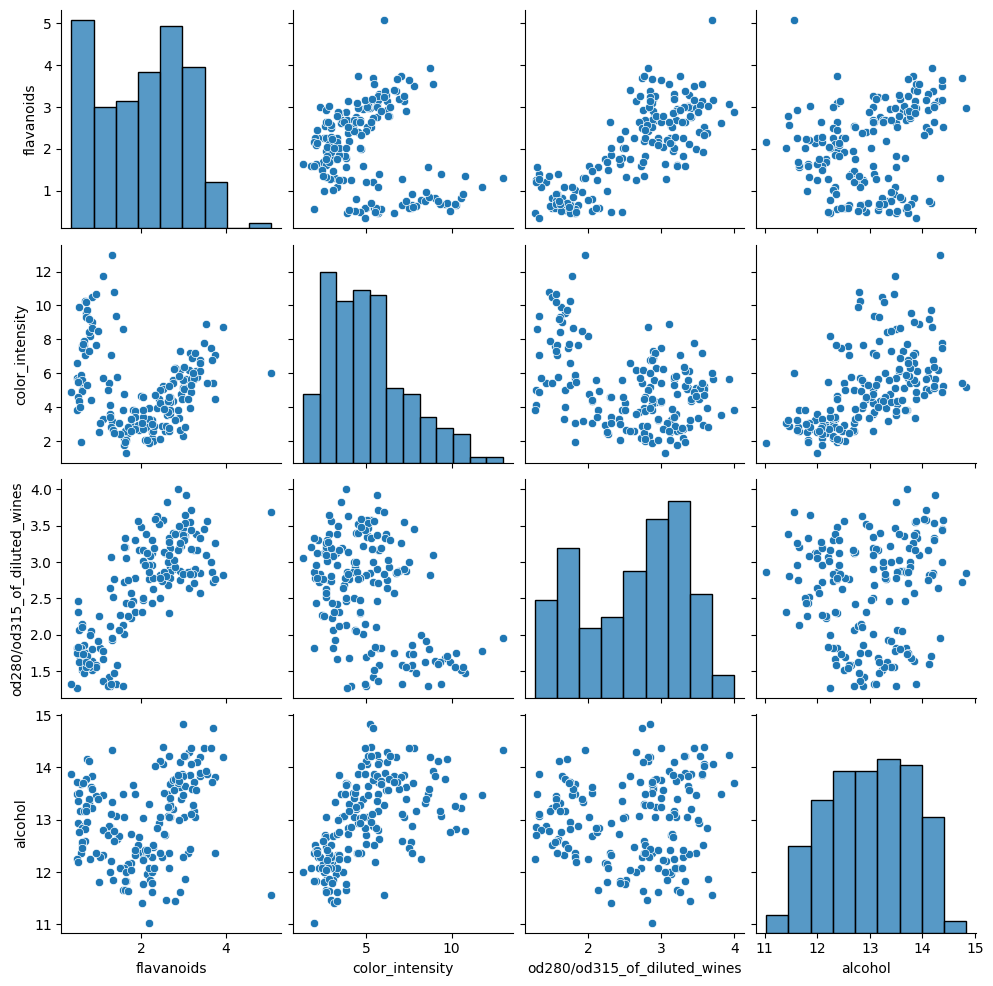

In [31]:
df = pd.DataFrame(X, columns=features)
sns.pairplot(df[["flavanoids", "color_intensity", "od280/od315_of_diluted_wines", "alcohol"]])
plt.show()

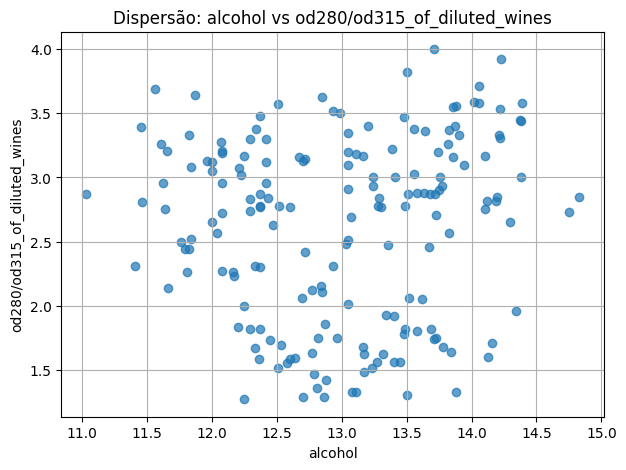

In [32]:
i = features.index("alcohol")
j = features.index("od280/od315_of_diluted_wines")

plt.figure(figsize=(7,5))
plt.scatter(X[:, i], X[:, j], alpha=0.7)
plt.xlabel("alcohol")
plt.ylabel("od280/od315_of_diluted_wines")
plt.title("Dispersão: alcohol vs od280/od315_of_diluted_wines")
plt.grid(True)
plt.show()

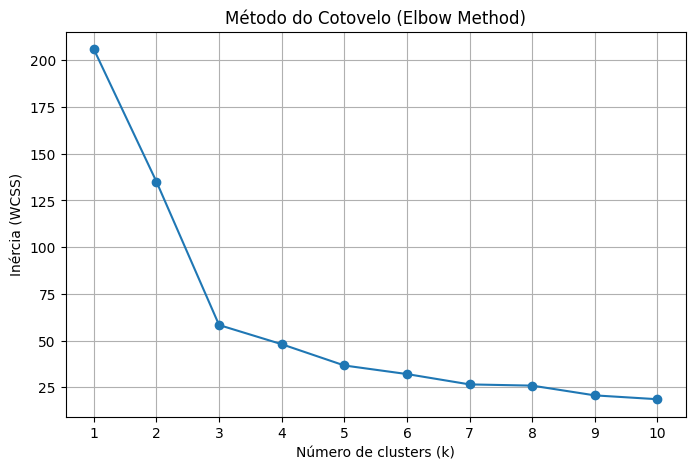

In [33]:
from sklearn.cluster import KMeans

X_pair = X[:, [i, j]]

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pair)
    inertias.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

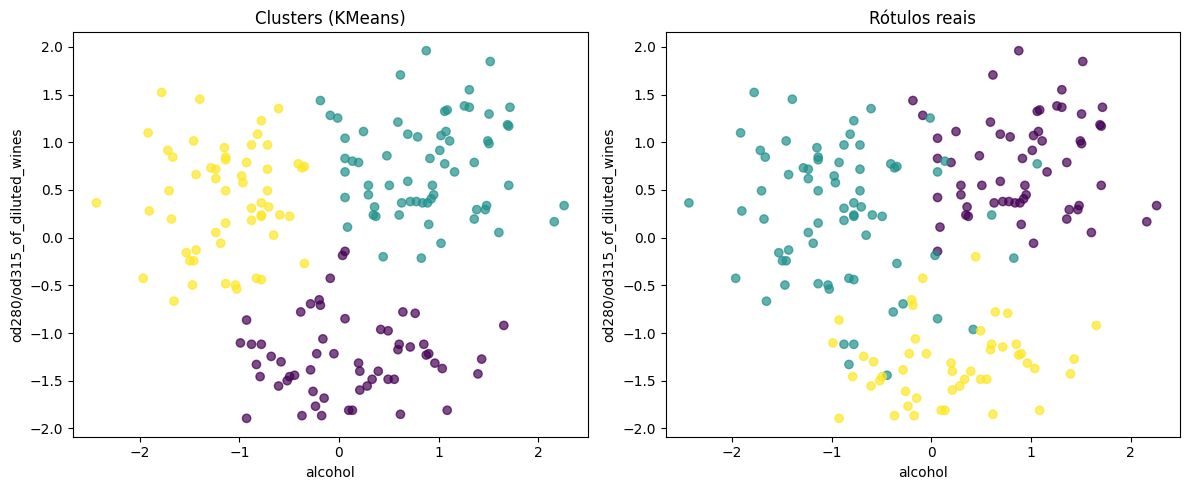

In [34]:
from sklearn.metrics import accuracy_score
import numpy as np

y = wine.target

kmeans = KMeans(n_clusters=3, random_state=314)
scalar = StandardScaler()
X_pair = scalar.fit_transform(X_pair)
r = kmeans.fit_predict(X_pair)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X_pair[:, 0], X_pair[:, 1], c=r, cmap='viridis', alpha=0.7)
axs[0].set_title("Clusters (KMeans)")
axs[0].set_xlabel("alcohol")
axs[0].set_ylabel("od280/od315_of_diluted_wines")

axs[1].scatter(X_pair[:, 0], X_pair[:, 1], c=y, cmap='viridis', alpha=0.7)
axs[1].set_title("Rótulos reais")
axs[1].set_xlabel("alcohol")
axs[1].set_ylabel("od280/od315_of_diluted_wines")

plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import numpy as np

def map_clusters_to_labels(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        labels[mask] = mode(y_true[mask], keepdims=True).mode[0]
    return labels

y_pred_adjusted = map_clusters_to_labels(wine.target, r)
acc = accuracy_score(y, y_pred_adjusted)
print(f"Taxa de acerto com 'od280/od315' e 'alcohol': {acc:.2f}")

Taxa de acerto com 'od280/od315' e 'alcohol': 0.90
